In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch
from PIL import Image

In [2]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Newcastle 2-1 Manchester United - Premier League 2025_2026 Live.html"
fotmob_matchId = 4813662

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)

In [3]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [4]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [7]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [8]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [9]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,goalMouthY,isShot,relatedEventId,relatedPlayerId,blockedX,blockedY,cardType,isGoal,teamName,oppositionTeamName
0,2.907303e+09,3,0,0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Newcastle
1,2.907303e+09,3,0,0,23,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Newcastle,Man Utd
2,2.907303e+09,4,0,0,32,60.12,40.32,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Newcastle
3,2.907303e+09,5,0,4,32,34.08,50.24,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Newcastle
4,2.907303e+09,4,0,7,23,35.64,3.12,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Newcastle,Man Utd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1493,2.907356e+09,859,98,17,32,0.00,0.00,108,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Newcastle
1494,2.907356e+09,801,0,0,23,0.00,0.00,18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Newcastle,Man Utd
1495,2.907356e+09,860,0,0,32,0.00,0.00,18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Newcastle
1496,2.907268e+09,2,0,0,23,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Newcastle,Man Utd


In [10]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,316858,32,Aaron Ramsdale,GK,True,A. Ramsdale
1,83078,2,Kieran Trippier,DR,True,K. Trippier
2,393355,12,Malick Thiaw,DC,True,M. Thiaw
3,82277,33,Dan Burn,DC,True,D. Burn
4,430294,3,Lewis Hall,DL,True,L. Hall
5,201755,7,Joelinton,MC,True,Joelinton
6,343501,8,Sandro Tonali,MC,True,S. Tonali
7,369813,41,Jacob Ramsey,MC,True,J. Ramsey
8,413211,20,Anthony Elanga,FWR,True,A. Elanga
9,349669,10,Anthony Gordon,FW,True,A. Gordon


In [11]:
df = df.merge(dfp, on='playerId', how='left')

In [12]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [13]:
df=df.reset_index()

In [14]:
df

,index,id,eventId,minute,second,teamId,x,y,expandedMinute,period,...,blockedY,cardType,isGoal,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2,2.907303e+09,4,0,0,32,60.12,40.32,0,NaN,...,NaN,NaN,NaN,Man Utd,Newcastle,8.0,Bruno Fernandes,AMC,True,B. Fernandes
1,3,2.907303e+09,5,0,4,32,34.08,50.24,0,NaN,...,NaN,NaN,NaN,Man Utd,Newcastle,31.0,Senne Lammens,GK,True,S. Lammens
2,9,2.907304e+09,7,0,10,23,33.24,2.24,0,NaN,...,NaN,NaN,NaN,Newcastle,Man Utd,2.0,Kieran Trippier,DR,True,K. Trippier
3,11,2.907304e+09,9,0,24,23,38.40,0.00,0,NaN,...,NaN,NaN,NaN,Newcastle,Man Utd,2.0,Kieran Trippier,DR,True,K. Trippier
4,12,2.907304e+09,10,0,26,23,32.88,24.24,0,NaN,...,NaN,NaN,NaN,Newcastle,Man Utd,33.0,Dan Burn,DC,True,D. Burn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,1483,2.907356e+09,854,97,4,32,78.96,47.12,107,NaN,...,NaN,NaN,NaN,Man Utd,Newcastle,8.0,Bruno Fernandes,AMC,True,B. Fernandes
990,1484,2.907356e+09,795,97,6,23,11.04,50.48,107,NaN,...,NaN,NaN,NaN,Newcastle,Man Utd,33.0,Dan Burn,DC,True,D. Burn
991,1488,2.907356e+09,799,97,59,23,42.84,75.92,107,NaN,...,NaN,NaN,NaN,Newcastle,Man Utd,32.0,Aaron Ramsdale,GK,True,A. Ramsdale
992,1490,2.907356e+09,857,98,4,32,27.84,2.40,108,NaN,...,NaN,NaN,NaN,Man Utd,Newcastle,2.0,Diogo Dalot,Sub,NaN,D. Dalot


In [15]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [16]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0,60.12,40.32,30.60,51.36,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,4,34.08,50.24,84.36,76.88,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
2,0,10,33.24,2.24,34.80,2.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
3,0,24,38.40,0.00,33.00,24.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
4,0,26,32.88,24.24,33.96,52.56,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,97,4,78.96,47.12,107.88,31.28,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
990,97,6,11.04,50.48,32.88,76.32,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN
991,97,59,42.84,75.92,93.72,77.76,Newcastle,32.0,GK,A. Ramsdale,NaN,NaN,NaN
992,98,4,27.84,2.40,30.00,32.88,Man Utd,2.0,Sub,D. Dalot,NaN,NaN,NaN


In [17]:
team1=df[df["teamName"]=="Newcastle"]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
2,0,10,33.24,2.24,34.80,2.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
3,0,24,38.40,0.00,33.00,24.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
4,0,26,32.88,24.24,33.96,52.56,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN
5,0,33,72.84,66.24,80.52,77.36,Newcastle,3.0,DL,L. Hall,NaN,NaN,NaN
6,0,36,82.92,69.92,77.40,58.40,Newcastle,11.0,FWL,H. Barnes,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,93,59,16.44,23.04,35.04,0.00,Newcastle,23.0,Sub,J. Murphy,NaN,NaN,NaN
978,95,5,17.76,37.92,86.04,24.32,Newcastle,32.0,GK,A. Ramsdale,NaN,NaN,NaN
987,95,36,8.40,25.92,26.88,0.00,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
990,97,6,11.04,50.48,32.88,76.32,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN


In [18]:
team2=df[df["teamName"]=="Man Utd"]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0,60.12,40.32,30.60,51.36,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,4,34.08,50.24,84.36,76.88,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
14,0,58,31.80,77.52,34.08,64.32,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
15,0,59,34.08,64.32,35.88,68.48,Man Utd,30.0,FW,B. Sesko,NaN,NaN,NaN
16,0,59,35.88,68.48,36.36,63.12,Man Utd,10.0,AML,M. Cunha,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,95,34,90.24,7.68,109.92,52.40,Man Utd,2.0,Sub,D. Dalot,NaN,NaN,NaN
988,97,0,88.80,80.00,78.96,52.08,Man Utd,12.0,Sub,T. Malacia,NaN,NaN,NaN
989,97,4,78.96,47.12,107.88,31.28,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
992,98,4,27.84,2.40,30.00,32.88,Man Utd,2.0,Sub,D. Dalot,NaN,NaN,NaN


In [21]:
firstSub1=46

In [22]:
team1=team1[team1["minute"]<firstSub1]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
2,0,10,33.24,2.24,34.80,2.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
3,0,24,38.40,0.00,33.00,24.24,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
4,0,26,32.88,24.24,33.96,52.56,Newcastle,33.0,DC,D. Burn,NaN,NaN,NaN
5,0,33,72.84,66.24,80.52,77.36,Newcastle,3.0,DL,L. Hall,NaN,NaN,NaN
6,0,36,82.92,69.92,77.40,58.40,Newcastle,11.0,FWL,H. Barnes,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,43,30,38.88,7.04,51.84,1.76,Newcastle,12.0,DC,M. Thiaw,NaN,NaN,NaN
475,43,32,51.72,2.24,57.96,16.08,Newcastle,2.0,DR,K. Trippier,NaN,NaN,NaN
477,43,37,28.68,20.88,48.84,30.56,Newcastle,12.0,DC,M. Thiaw,NaN,NaN,NaN
478,43,43,66.12,42.56,71.16,80.00,Newcastle,7.0,MC,Joelinton,NaN,NaN,NaN


In [23]:
firstSub2=61

In [24]:
team2=team2[team2["minute"]<firstSub2]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0,60.12,40.32,30.60,51.36,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,4,34.08,50.24,84.36,76.88,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
14,0,58,31.80,77.52,34.08,64.32,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
15,0,59,34.08,64.32,35.88,68.48,Man Utd,30.0,FW,B. Sesko,NaN,NaN,NaN
16,0,59,35.88,68.48,36.36,63.12,Man Utd,10.0,AML,M. Cunha,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,59,25,84.84,51.84,101.64,26.72,Man Utd,10.0,AML,M. Cunha,NaN,NaN,NaN
701,59,35,92.28,53.28,114.96,46.16,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
702,59,39,114.48,53.04,109.20,48.24,Man Utd,19.0,AMR,B. Mbeumo,NaN,NaN,NaN
703,59,40,115.32,52.80,120.00,15.44,Man Utd,19.0,AMR,B. Mbeumo,NaN,NaN,NaN


In [25]:
response=requests.get("https://www.sofascore.com/football/match/newcastle-united-manchester-united/DYBe#id:14023983,tab:statistics")

In [26]:
soup=BeautifulSoup(response.text,"html.parser")

In [27]:
soup.select('g[cursor="pointer"]')

[]

In [28]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9,hi;q=0.8',
    'referer': 'https://www.sofascore.com/football/match/newcastle-united-manchester-united/DYBe',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
}

url='https://www.sofascore.com/api/v1/event/14023983/shotmap'

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [29]:
shots=response.json()

In [30]:
df_shots=pd.json_normalize(shots["shotmap"])

In [31]:
df_shots

,isHome,shotType,goalType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,...,player.sofascoreId,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,goalkeeper.sofascoreId,draw.block.x,draw.block.y,player.firstName,player.lastName,addedTime
0,True,goal,regular,fast-break,left-foot,low-left,0.045502,0.740013,6827807,90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,save,NaN,assisted,right-foot,high-right,0.022914,0.059663,6827797,89,...,JZirkzee,1.1,53.6,0.0,ARamsdale,53.6,1.1,NaN,NaN,NaN
2,False,block,NaN,assisted,right-foot,low-centre,0.091551,0.000000,6827801,88,...,ugartemanu,11.5,52.7,0.0,ARamsdale,52.7,11.5,NaN,NaN,NaN
3,False,block,NaN,assisted,left-foot,low-left,0.181399,0.000000,6827799,88,...,benjamin_sesko,10.3,48.6,0.0,ARamsdale,48.6,10.3,NaN,NaN,NaN
4,False,miss,NaN,assisted,right-foot,high-right,0.029885,0.000000,6827759,82,...,BrunoFernandes,NaN,NaN,NaN,ARamsdale,NaN,NaN,NaN,NaN,NaN
5,True,save,NaN,set-piece,head,high-centre,0.590792,0.805380,6827762,79,...,MThiaw,1.1,49.6,0.0,NaN,49.6,1.1,NaN,NaN,NaN
6,False,miss,NaN,assisted,head,close-high,0.095509,0.000000,6827715,76,...,ugartemanu,NaN,NaN,NaN,ARamsdale,NaN,NaN,NaN,NaN,NaN
7,False,save,NaN,corner,head,low-centre,0.258904,0.362533,6827714,75,...,YL15,1.2,52.2,0.0,ARamsdale,52.2,1.2,Leny Yoro,,NaN
8,False,block,NaN,assisted,right-foot,low-centre,0.055691,0.000000,6827707,70,...,nousmaz97,14.9,47.5,0.0,ARamsdale,47.5,14.9,NaN,NaN,NaN
9,True,miss,NaN,corner,right-foot,right,0.509966,0.000000,6827675,66,...,AGordon,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN


In [32]:
df_shots=df_shots.sort_values("time").reset_index()
df_shots

,index,isHome,shotType,goalType,situation,bodyPart,goalMouthLocation,xg,xgot,id,...,player.sofascoreId,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,goalkeeper.sofascoreId,draw.block.x,draw.block.y,player.firstName,player.lastName,addedTime
0,25,True,miss,NaN,regular,right-foot,close-high,0.056726,0.000000,6827195,...,lewishall_10,NaN,NaN,NaN,NaN,NaN,NaN,Lewis Hall,NaN,NaN
1,24,False,miss,NaN,assisted,right-foot,high-right,0.102611,0.000000,6827208,...,Cunha,NaN,NaN,NaN,ARamsdale,NaN,NaN,NaN,NaN,NaN
2,23,True,block,NaN,assisted,right-foot,low-centre,0.031131,0.000000,6827213,...,NaN,12.8,36.6,0.0,NaN,36.6,12.8,,,NaN
3,22,True,miss,NaN,throw-in-set-piece,right-foot,close-right,0.069386,0.000000,6827248,...,anthonyelanga,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
4,21,True,miss,NaN,assisted,right-foot,close-high-right,0.097811,0.000000,6827250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
5,20,True,miss,NaN,regular,right-foot,left,0.019597,0.000000,6827267,...,sandrotonali,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
6,19,False,block,NaN,regular,right-foot,low-right,0.138387,0.000000,6827343,...,benjamin_sesko,6.0,49.5,0.0,ARamsdale,49.5,6.0,NaN,NaN,NaN
7,18,True,miss,NaN,fast-break,right-foot,high,0.119718,0.000000,6827409,...,joelinton34,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
8,17,True,save,NaN,assisted,right-foot,low-centre,0.129828,0.185961,6827439,...,NaN,0.9,53.4,0.0,NaN,53.4,0.9,,,NaN
9,16,False,save,NaN,assisted,right-foot,high-left,0.029377,0.120423,6827470,...,KobbieM,2.8,52.0,0.0,ARamsdale,52.0,2.8,Kobbie,Mainoo,NaN


In [33]:
df_shots=df_shots[["isHome","shotType","xg","time","player.shortName","player.jerseyNumber","playerCoordinates.x","playerCoordinates.y",
        "goalMouthCoordinates.x","goalMouthCoordinates.y"]]

In [34]:
df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
df_shots["goalMouthCoordinates.x"]=df_shots["goalMouthCoordinates.x"]*1.2
df_shots["goalMouthCoordinates.y"]=df_shots["goalMouthCoordinates.y"]*0.8

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\3668136620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\3668136620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\3668136620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [35]:
for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==False):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
    if (df_shots["isHome"][x]==True):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\4112479664.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
C:\Users\K Raghunandan\AppData\Local\Temp\ipy

In [36]:
team1_shots=df_shots[df_shots["isHome"]==True]
team1_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,True,miss,0.056726,3,L. Hall,3,10.68,51.68,0.0,44.40
2,True,block,0.031131,9,H. Barnes,11,17.04,51.92,0.0,39.60
3,True,miss,0.069386,13,A. Elanga,20,11.28,29.04,0.0,33.60
4,True,miss,0.097811,14,H. Barnes,11,21.96,42.56,0.0,34.80
5,True,miss,0.019597,20,S. Tonali,8,28.80,49.20,0.0,48.80
7,True,miss,0.119718,34,Joelinton,7,25.56,41.36,0.0,40.72
8,True,save,0.129828,41,H. Barnes,11,3.24,33.68,0.0,38.72
10,True,goal,0.788400,45,A. Gordon,10,13.80,40.00,0.0,40.08
15,True,save,0.023304,53,A. Gordon,10,27.84,33.36,0.0,38.64
16,True,miss,0.509966,66,A. Gordon,10,3.60,35.52,0.0,32.16


In [37]:
team2_shots=df_shots[df_shots["isHome"]==False]
team2_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
1,False,miss,0.102611,7,M. Cunha,10,22.08,43.68,0.0,26.64
6,False,block,0.138387,24,B. Šeško,30,11.04,41.68,0.0,38.08
9,False,save,0.029377,42,K. Mainoo,37,27.12,28.48,0.0,42.32
11,False,block,0.058479,45,M. Cunha,10,15.24,50.96,0.0,39.60
12,False,goal,0.073050,45,Casemiro,18,8.04,34.00,0.0,41.04
13,False,save,0.022411,45,M. Cunha,10,15.24,55.68,0.0,39.12
14,False,miss,0.328656,45,B. Mbeumo,19,9.84,35.36,0.0,41.84
17,False,block,0.055691,70,N. Mazraoui,3,25.08,42.56,0.0,40.72
18,False,save,0.258904,75,L. Yoro,15,7.80,35.28,0.0,40.96
19,False,miss,0.095509,76,M. Ugarte,25,11.52,43.92,0.0,38.16


In [38]:
a_xG=[0]
h_xG=[0]
a_min=[0]
h_min=[0]

for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==True):
        h_xG.append(df_shots["xg"][x])
        h_min.append(df_shots["time"][x])
    if (df_shots["isHome"][x]==False):
        a_xG.append(df_shots["xg"][x])
        a_min.append(df_shots["time"][x])

In [39]:
def nums_cumulative_sum(nums_list):
    return [sum(nums_list[:i+1]) for i in range(len(nums_list))]

a_cum=nums_cumulative_sum(a_xG)
h_cum=nums_cumulative_sum(h_xG)

In [40]:
a_total=round(a_cum[-1],2)
h_total=round(h_cum[-1],2)

In [42]:
def create_passnetwork(df, ax,color):
    df["passer"]=df["shirtNo"]
    df["recipient"]=df["shirtNo"].shift(-1)

    pas=pd.to_numeric(df["passer"],downcast="integer")
    rec=pd.to_numeric(df["recipient"],downcast="integer")

    df["passer"]=pas
    df["recipient"]=rec

    df=df.drop(["goalMouthY","isShot","isGoal"],axis=1)

    average_locations=df.groupby("passer").agg({"x":["mean"],"y":["mean","count"]})
    average_locations.columns=["x","y","count"]
    average_locations

    pass_between = (
    df
    .groupby(["passer", "recipient"])
    .size()
    .reset_index(name="pass_count")
    )

    pass_between = pass_between.merge(average_locations, left_on='passer', right_index=True)
    pass_between = pass_between.merge(average_locations, left_on='recipient', right_index=True, suffixes=['', '_end'])

    pass_between=pass_between[pass_between["pass_count"]>3]

    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A')
    pitch.draw(ax=ax)
    plt.gca().invert_xaxis()

    arrows=pitch.arrows(pass_between.x,
                        pass_between.y,
                        pass_between.x_end,
                        pass_between.y_end,
                        ax=ax,
                        width=4.2,
                        headwidth=4.2,
                        color=color,
                        alpha=.85)
    
    nodes=pitch.scatter(average_locations.x,
                    average_locations.y,
                    s=500,
                    color="#d3d3d3",
                    edgecolor="black",
                    linewidth=2.5,
                    alpha=1,
                    ax=ax)

    for passer, row in average_locations.iterrows():
        pitch.annotate(
            str(passer),
            xy=(row['x'], row['y']),
            ha='center',
            va='center',
            fontsize=9,
            color='black',
            weight='bold',
            ax=ax
        )

In [70]:
def create_xg_flowchart(df, ax, h_color, a_color):
    ax.patch.set_facecolor("#EAEAEA")
    
    plt.xticks([0,15,30,45,60,75,90])
    plt.xlabel("Minutes")
    plt.ylabel("xG")

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    df['cumulative_xG'] = df.groupby('isHome')['xg'].cumsum()

    ax.step(x=a_min,y=a_cum,where="post",color=a_color)
    ax.step(x=h_min,y=h_cum,where="post",color=h_color)

    for x in range(len(df["playerCoordinates.x"])):
        if (df["isHome"][x]==True):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=h_color,zorder=5)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
        if (df["isHome"][x]==False):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=a_color)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )

In [71]:
def create_shotmap(df, ax, color):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A',half=True)
    pitch.draw(ax=ax, constrained_layout=True, tight_layout=False)
    plt.gca().invert_yaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,45)

    for x in df.to_dict(orient='records'):
        pitch.scatter(
            x=x["playerCoordinates.x"], y=x["playerCoordinates.y"], ax=ax, 
            s=500 * x['xg'], 
            facecolor=color if x['shotType'] == 'goal' else "#EAEAEA", 
            edgecolors=color, alpha=0.7
        )

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\3893633159.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cumulative_xG'] = df.groupby('isHome')['xg'].cumsum()
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\1443387154.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["passer"]=df["shirtNo"]
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_13368\1443387154.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

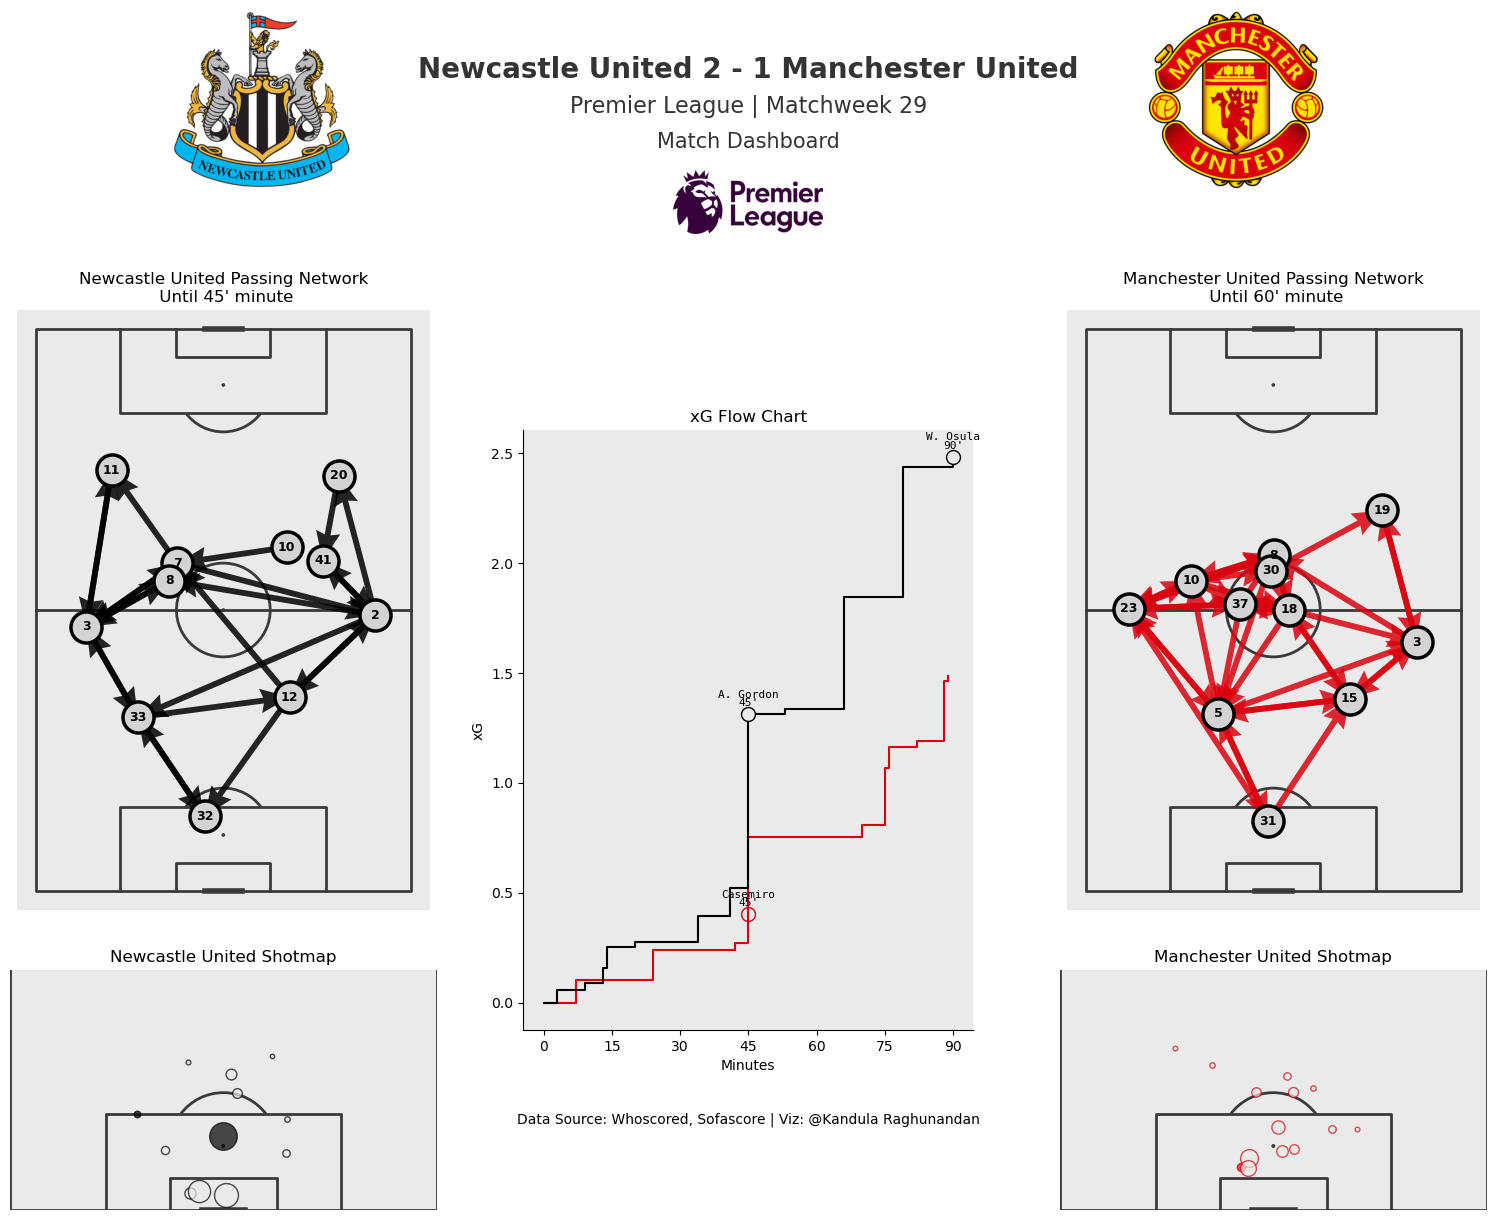

In [73]:
fig = plt.figure(figsize=(15,12))

ax1=fig.add_axes([0.25, 0.9, 0.15, 0.15])
team1_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Newcastle United.png")
ax1.imshow(team1_img)
ax1.axis("off")

ax2=fig.add_axes([0.6, 0.84, 0.10, 0.10])
league_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")
ax2.imshow(league_img)
ax2.axis("off")

ax3=fig.add_axes([0.9, 0.9, 0.15, 0.15])
team2_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png")
ax3.imshow(team2_img)
ax3.axis("off")

ax4=fig.add_axes([.15,.3,.3,.5])
create_passnetwork(team1,ax4, "#000000")
ax4.set_title("Newcastle United Passing Network\n Until 45' minute")

ax5=fig.add_axes([.5,.2,.3,.5])
create_xg_flowchart(df_shots, ax5, "#000000", "#DA020E")
ax5.set_title("xG Flow Chart")

plt.text(
    0.5, -0.15, "Data Source: Whoscored, Sofascore | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="black"
)

ax6=fig.add_axes([.85,.3,.3,.5])
create_passnetwork(team2,ax6, "#DA020E")
ax6.set_title("Manchester United Passing Network\n Until 60' minute")

ax7=fig.add_axes([.15,.05,.3,.2])
create_shotmap(team1_shots,ax7, "#000000")
ax7.set_title("Newcastle United Shotmap")

ax8=fig.add_axes([.85,.05,.3,.2])
create_shotmap(team2_shots,ax8, "#DA020E")
ax8.set_title("Manchester United Shotmap")

fig.text(0.65, 1, "Newcastle United 2 - 1 Manchester United", fontsize=20, fontweight='bold', color='#343434', ha="center", va="center")
fig.text(0.65, 0.97, "Premier League | Matchweek 29", fontsize=16, color='#343434', ha="center", va="center")
fig.text(0.65, 0.94, "Match Dashboard", fontsize=15, color='#343434', ha="center", va="center" )


fig.savefig("C:/Users/K Raghunandan/Analyst/Matches/Newcastle 2-1 Manchester United - Premier League 2025_2026 Live_files/New folder/new_vs_mun_4-3-26.png", bbox_inches='tight')